# Procesos mixtos AR[I]MA - Bitcoin

**Objetivo:** Aplicar un modelo ARIMA a la serie temporal de precios de Bitcoin, determinar los órdenes óptimos, evaluar el modelo y realizar predicciones.

Basado en la metodología de la Sesión 41 (IBEX 35), aplicada ahora a criptomonedas.

In [16]:
# Importar librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

## 1. Carga y preparación de datos

Usamos datos históricos de Bitcoin descargados de la api de coingecko. Bitcoin cotiza 24/7, por lo que la frecuencia es diaria sin excluir fines de semana.

In [17]:
# Leemos los datos de Bitcoin
df_full = pd.read_csv('Bitcoin.csv')
df_full['Date'] = pd.to_datetime(df_full['Date'])
df_full = df_full.set_index('Date')

# Usamos el último año de datos (comparable al ejercicio del IBEX)
df = df_full.loc['2024-03-18':].copy() # tengo los datos hasta el 18 de marzo de 2025...

# Bitcoin cotiza 24/7, no es como la bolsa, así que aseguramos frecuencia diaria y rellenamos huecos
df = df.asfreq('D').ffill()

print(df.head())
print(f"\nPeriodo: {df.index[0].date()} a {df.index[-1].date()}")
print(f"Número de observaciones: {len(df)}")

# Comprobamos que no hay valores NaN
print(f"\nValores NaN por columna:")
print(df.isnull().sum())

            Unnamed: 0          Open          High           Low  \
Date                                                               
2024-03-18        3470  68371.304688  68897.132812  66594.226562   
2024-03-19        3471  67556.132812  68106.929688  61536.179688   
2024-03-20        3472  61930.156250  68115.257812  60807.785156   
2024-03-21        3473  67911.585938  68199.992188  64580.917969   
2024-03-22        3474  65489.929688  66623.750000  62355.371094   

                   Close       Volume  Dividends  Stock Splits  
Date                                                            
2024-03-18  67548.593750  49261579492        0.0           0.0  
2024-03-19  61912.773438  74215844794        0.0           0.0  
2024-03-20  67913.671875  66792634382        0.0           0.0  
2024-03-21  65491.390625  44480350565        0.0           0.0  
2024-03-22  63778.761719  41401116964        0.0           0.0  

Periodo: 2024-03-18 a 2025-03-18
Número de observaciones: 366

Valo

## 2. Visualización de la serie original

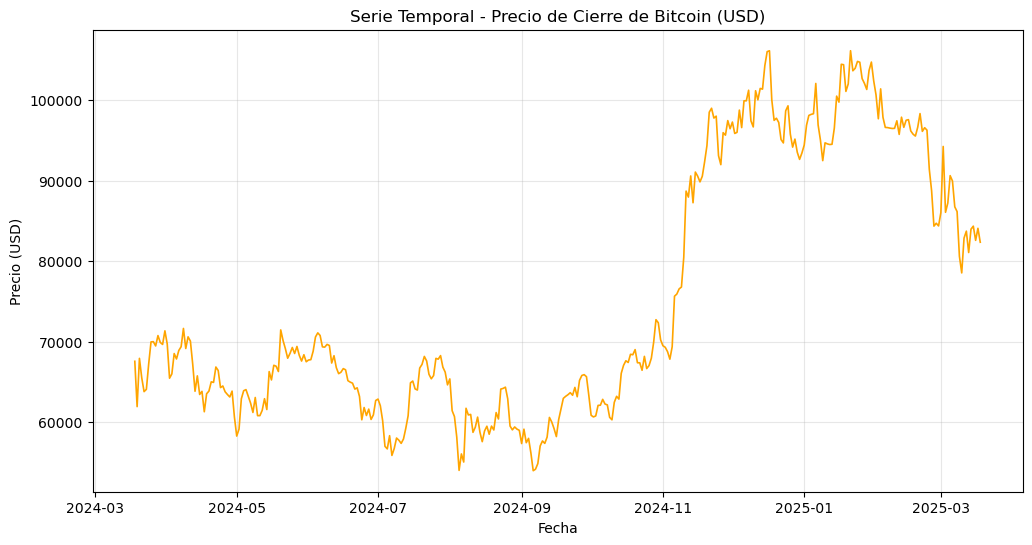

In [18]:
# Visualizamos la serie
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], color='orange', linewidth=1.2)
plt.title('Serie Temporal - Precio de Cierre de Bitcoin (USD)')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.grid(True, alpha=0.3)
plt.show()

## 3. ACF y PACF de la serie original

Visualizamos la función de autocorrelación (ACF) y autocorrelación parcial (PACF) para identificar patrones en la serie.

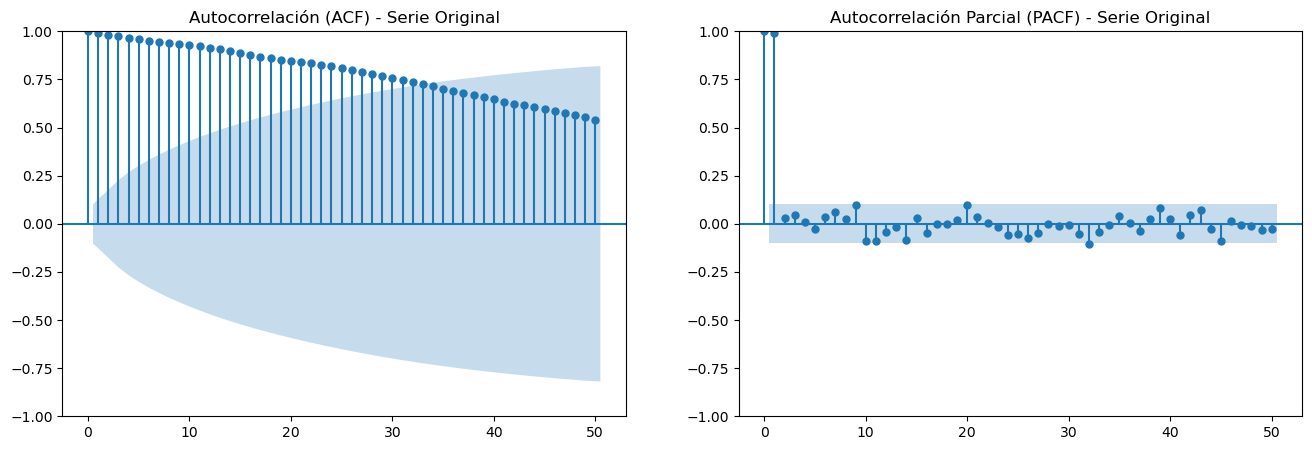

In [19]:
# Visualizamos la función de autocorrelación (ACF) y autocorrelación parcial (PACF)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df['Close'], lags=50, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Serie Original')
plot_pacf(df['Close'], lags=50, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF) - Serie Original')
plt.show()

**Observación:** La ACF decae muy lentamente, lo que indica que la serie **NO es estacionaria**. Esto es esperable en precios de activos financieros como Bitcoin.

## 4. Diferenciación y ACF/PACF de la serie diferenciada

Aplicamos diferenciación de orden 1 para eliminar la tendencia y lograr estacionariedad.

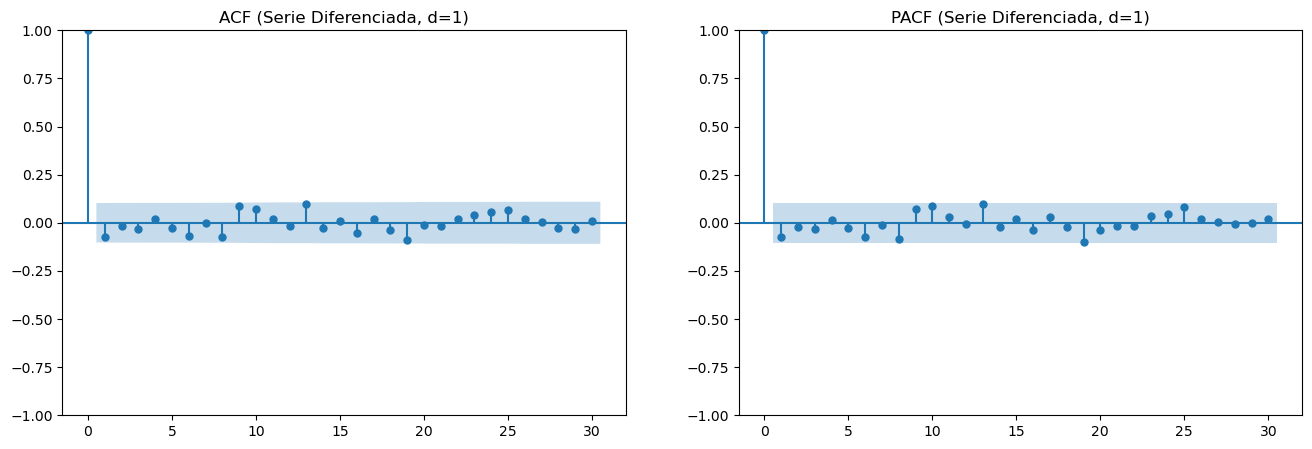

In [20]:
# ACF y PACF usando diferenciación
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df['Close'].diff().dropna(), ax=ax1, lags=30)
ax1.set_title('ACF (Serie Diferenciada, d=1)')

plot_pacf(df['Close'].diff().dropna(), ax=ax2, lags=30)
ax2.set_title('PACF (Serie Diferenciada, d=1)')

plt.show()

**Observación:** Tras la diferenciación, las autocorrelaciones caen rápidamente dentro de las bandas de confianza, lo que sugiere que la serie diferenciada **es estacionaria**.

## 5. Comparativa: Serie original vs diferenciada

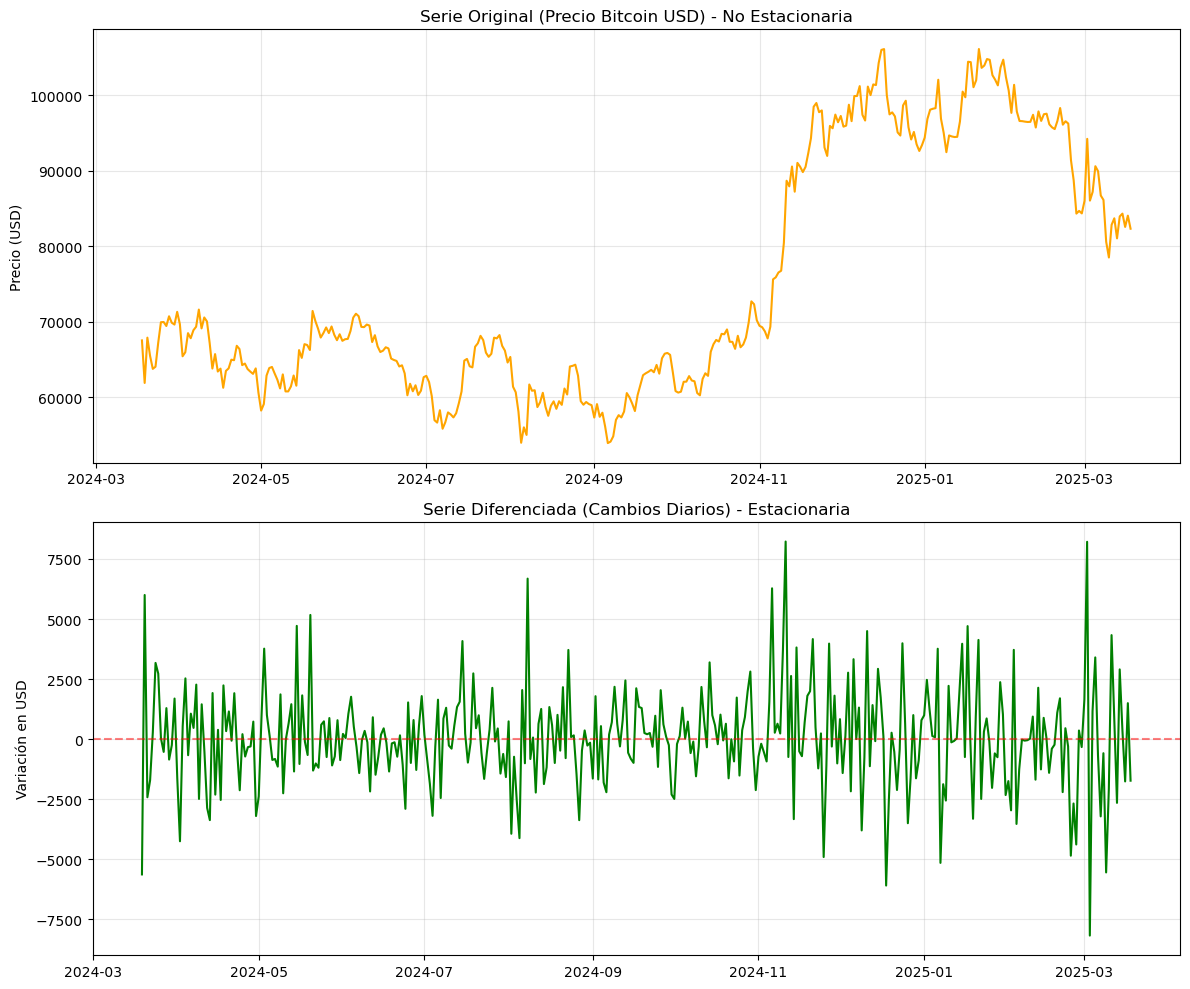

In [21]:
# Comparativa visual
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 1. Serie Original
ax1.plot(df.index, df['Close'], color='orange')
ax1.set_title('Serie Original (Precio Bitcoin USD) - No Estacionaria')
ax1.set_ylabel('Precio (USD)')
ax1.grid(True, alpha=0.3)

# 2. Serie Diferenciada
df_diff = df['Close'].diff().dropna()
ax2.plot(df_diff.index, df_diff, color='green')
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax2.set_title('Serie Diferenciada (Cambios Diarios) - Estacionaria')
ax2.set_ylabel('Variación en USD')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Test de Dickey-Fuller Aumentado

Verificamos formalmente si la diferenciación es suficiente para lograr estacionariedad.

In [22]:
# Test ADF sobre la serie original
resultado_orig = adfuller(df['Close'].dropna())
print("--- Serie Original ---")
print(f"Estadístico ADF: {resultado_orig[0]:.6f}")
print(f"p-value: {resultado_orig[1]:.6f}")
print(f"Conclusión: {'Estacionaria' if resultado_orig[1] < 0.05 else 'NO estacionaria'} (α=0.05)")

print()

# Test ADF sobre la serie diferenciada
resultado_diff = adfuller(df['Close'].diff().dropna())
print("--- Serie Diferenciada (d=1) ---")
print(f"Estadístico ADF: {resultado_diff[0]:.6f}")
print(f"p-value: {resultado_diff[1]:.2e}")
print(f"Conclusión: {'Estacionaria' if resultado_diff[1] < 0.05 else 'NO estacionaria'} (α=0.05)")

if resultado_diff[1] < 0.05:
    print("\n✓ La diferenciación de orden 1 es suficiente para lograr estacionariedad.")

--- Serie Original ---
Estadístico ADF: -1.262644
p-value: 0.646085
Conclusión: NO estacionaria (α=0.05)

--- Serie Diferenciada (d=1) ---
Estadístico ADF: -20.677259
p-value: 0.00e+00
Conclusión: Estacionaria (α=0.05)

✓ La diferenciación de orden 1 es suficiente para lograr estacionariedad.


## 7. Ajuste del modelo ARIMA(1,1,1)

Comenzamos con un modelo ARIMA(1,1,1) como punto de partida, igual que en el ejercicio del IBEX.

In [23]:
# Ajustar un modelo ARIMA(1,1,1)
model = ARIMA(df['Close'], order=(1, 1, 1))
model_fit = model.fit()

# Resumen del modelo
print(model_fit.summary())

# Raíces para comprobar estacionariedad
print("\nRaíces AR (Deben estar fuera del círculo unitario):")
print(model_fit.arroots)
print("Raíces MA (Deben estar fuera del círculo unitario):")
print(model_fit.maroots)

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  366
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3298.444
Date:                Fri, 27 Feb 2026   AIC                           6602.888
Time:                        23:52:15   BIC                           6614.587
Sample:                    03-18-2024   HQIC                          6607.537
                         - 03-18-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5583      0.201     -2.779      0.005      -0.952      -0.165
ma.L1          0.4683      0.226      2.069      0.039       0.025       0.912
sigma2      4.113e+06   2.11e+05     19.516      0.0

**Observación:** En el ARIMA(1,1,1), los coeficientes AR y MA son estadísticamente significativos (p-values < 0.05), pero el AIC (6602.89) es superior al de otros modelos explorados. Busquemos los órdenes óptimos para minimizar el AIC.

## 8. Búsqueda de órdenes óptimos mediante AIC

Probamos diferentes combinaciones de (p, d, q) y seleccionamos el modelo con menor AIC.

In [24]:
# Buscamos los mejores órdenes
best_aic = float('inf')
best_order = None
results_table = []

for p in range(0, 4):
    for q in range(0, 4):
        try:
            model_test = ARIMA(df['Close'], order=(p, 1, q))
            fit_test = model_test.fit()
            results_table.append({'p': p, 'd': 1, 'q': q, 'AIC': fit_test.aic, 'BIC': fit_test.bic})
            if fit_test.aic < best_aic:
                best_aic = fit_test.aic
                best_order = (p, 1, q)
        except:
            pass

results_df = pd.DataFrame(results_table).sort_values('AIC')
print("Top 10 modelos por AIC:")
print(results_df.head(10).to_string(index=False))
print(f"\n★ Mejor modelo: ARIMA{best_order} con AIC = {best_aic:.2f}")

Top 10 modelos por AIC:
 p  d  q         AIC         BIC
 2  1  3 6592.783661 6616.183046
 1  1  1 6602.887656 6614.587348
 2  1  0 6603.054589 6614.754281
 0  1  3 6603.665807 6619.265396
 0  1  2 6603.791849 6615.491541
 3  1  0 6603.917551 6619.517140
 1  1  2 6604.341643 6619.941232
 2  1  1 6604.406432 6620.006021
 1  1  0 6604.888207 6612.688001
 1  1  3 6605.513826 6625.013313

★ Mejor modelo: ARIMA(2, 1, 3) con AIC = 6592.78


## 9. Ajuste del modelo óptimo

In [25]:
# Ajustmos el modelo óptimo
model_best = ARIMA(df['Close'], order=best_order)
model_best_fit = model_best.fit()

print(model_best_fit.summary())

# Raíces del modelo óptimo
print("\n--- Raíces del modelo óptimo ---")
if len(model_best_fit.arroots) > 0:
    print(f"Raíces AR: {model_best_fit.arroots}")
    print(f"  Todas fuera del círculo unitario: {all(abs(r) > 1 for r in model_best_fit.arroots)}")
if len(model_best_fit.maroots) > 0:
    print(f"Raíces MA: {model_best_fit.maroots}")
    print(f"  Todas fuera del círculo unitario: {all(abs(r) > 1 for r in model_best_fit.maroots)}")

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  366
Model:                 ARIMA(2, 1, 3)   Log Likelihood               -3290.392
Date:                Fri, 27 Feb 2026   AIC                           6592.784
Time:                        23:52:15   BIC                           6616.183
Sample:                    03-18-2024   HQIC                          6602.083
                         - 03-18-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2473      0.064     -3.868      0.000      -0.373      -0.122
ar.L2         -0.8621      0.045    -19.313      0.000      -0.950      -0.775
ma.L1          0.1596      0.077      2.083      0.0

## 10. Diagnóstico e interpretación

### Pruebas de diagnóstico:

- **Ljung-Box (Prob(Q)):** Evalúa si los residuos están autocorrelacionados.
  - Prob(Q) > 0.05 → Los residuos no muestran autocorrelación significativa ✓

- **Jarque-Bera (Prob(JB)):** Evalúa si los residuos siguen una distribución normal.
  - Prob(JB) < 0.05 → Los residuos NO siguen distribución normal ✗
  - Esto es **habitual en series financieras** por la presencia de colas pesadas.

- **Heteroscedasticidad (Prob(H)):** Evalúa si la varianza de los residuos es constante.
  - Prob(H) < 0.05 → Varianza no constante (heteroscedasticidad) ✗
  - Esto sugiere que un modelo GARCH podría complementar al ARIMA.

- **Skewness (Asimetría):** Valor cercano a 0 → distribución aproximadamente simétrica.
- **Kurtosis:** Valor > 3 → distribución leptocúrtica (colas pesadas), típico en finanzas.

## 11. Predicción a futuro (5 días)

In [26]:
# Predicción directa a futuro
steps = 5
forecast_obj = model_best_fit.get_forecast(steps=steps)
media_predicha = forecast_obj.predicted_mean
intervalo_confianza = forecast_obj.conf_int()

print("Intervalo de confianza (95%):")
print(intervalo_confianza)
print(f"\nMedia predicha:")
print(media_predicha)

Intervalo de confianza (95%):
             lower Close   upper Close
2025-03-19  78495.012670  86446.013306
2025-03-20  76866.267458  87629.071062
2025-03-21  75655.003088  89010.589604
2025-03-22  74795.606133  90212.119466
2025-03-23  73883.227724  90893.118268

Media predicha:
2025-03-19    82470.512988
2025-03-20    82247.669260
2025-03-21    82332.796346
2025-03-22    82503.862799
2025-03-23    82388.172996
Freq: D, Name: predicted_mean, dtype: float64


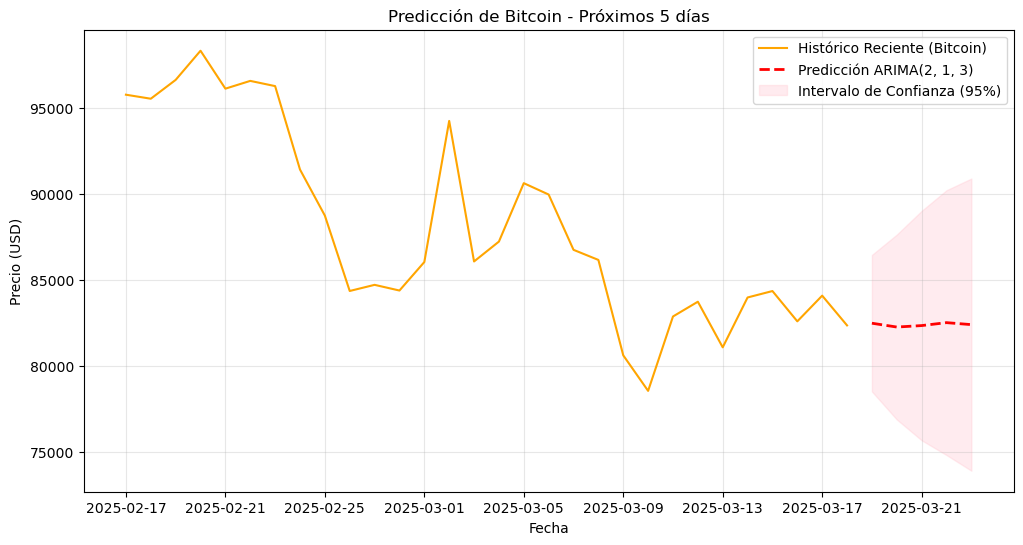

In [27]:
# Visualización de la predicción
plt.figure(figsize=(12, 6))

# Últimos 30 días reales para contexto
ultimos_datos = df['Close'].tail(30)
plt.plot(ultimos_datos.index, ultimos_datos, label='Histórico Reciente (Bitcoin)', color='orange', linewidth=1.5)

# Predicción
plt.plot(media_predicha.index, media_predicha, label=f'Predicción ARIMA{best_order}', color='red', linestyle='--', linewidth=2)

# Intervalo de confianza
plt.fill_between(intervalo_confianza.index,
                 intervalo_confianza.iloc[:, 0],
                 intervalo_confianza.iloc[:, 1],
                 color='pink', alpha=0.3, label='Intervalo de Confianza (95%)')

plt.title(f'Predicción de Bitcoin - Próximos {steps} días')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. Predicción sobre la serie completa (In-Sample)

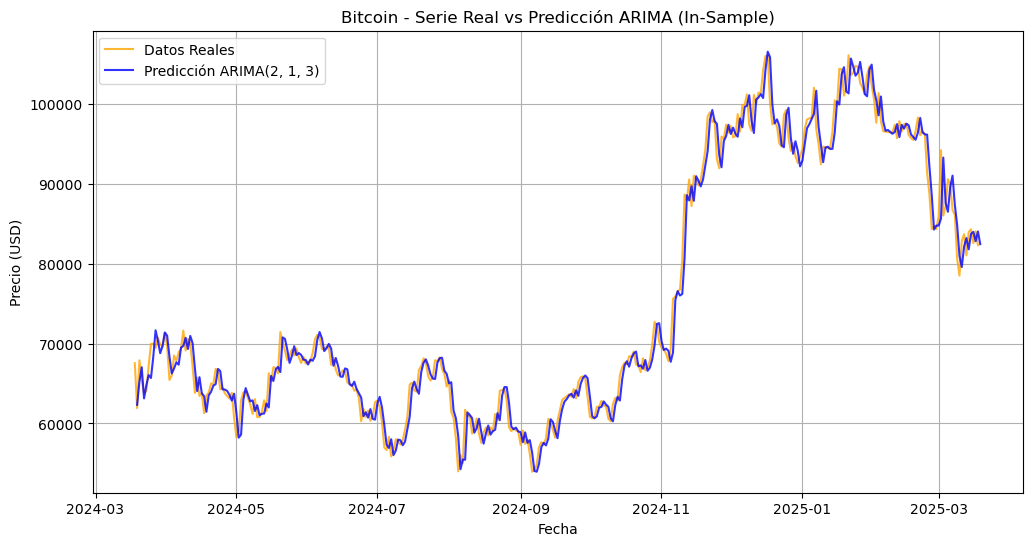

In [28]:
# Predecimos valores para toda la serie
predictions = model_best_fit.predict(start=1, end=len(df))

plt.figure(figsize=(12, 6))
plt.plot(df['Close'], color='orange', label='Datos Reales', alpha=0.8)
plt.plot(predictions, color='blue', label=f'Predicción ARIMA{best_order}', alpha=0.8)
plt.title('Bitcoin - Serie Real vs Predicción ARIMA (In-Sample)')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

## 13. Conclusiones

### Hallazgos principales:

**1. Estacionariedad:**
- La serie original de precios de Bitcoin **NO es estacionaria** (test ADF, p-value = 0.65).
- Tras una diferenciación de orden 1 (d=1), la serie **sí es estacionaria** (p-value ≈ 0), confirmado tanto por el test ADF como por el análisis visual de ACF/PACF.

**2. Modelo seleccionado:**
- El modelo ARIMA(1,1,1) inicial mostró coeficientes no significativos.
- Mediante búsqueda por AIC, el modelo óptimo resultó ser **ARIMA(2,1,3)** (AIC = 6592.78).
- La mayoría de los coeficientes del modelo óptimo son estadísticamente significativos (p-value < 0.05), aunque `ma.L3` presenta p-value = 0.088 (ligeramente por encima del umbral).

**3. Diagnóstico del modelo:**
- **Ljung-Box (Prob(Q) = 0.48 > 0.05):** Los residuos NO presentan autocorrelación significativa → el modelo captura bien la estructura temporal. ✓
- **Jarque-Bera (Prob(JB) = 0.00 < 0.05):** Los residuos NO son normales → presencia de colas pesadas, habitual en finanzas. ✗
- **Heteroscedasticidad (Prob(H) = 0.00 < 0.05):** La varianza no es constante → periodos de alta y baja volatilidad. ✗
- **Skewness (0.40):** Ligera asimetría positiva, indicando colas más largas hacia valores altos.
- **Kurtosis (5.11 > 3):** Distribución leptocúrtica, confirmando las colas pesadas.
- Las raíces AR y MA están fuera del círculo unitario → **modelo estable**.
- **Nota:** El modelo muestra un warning sobre la matriz de covarianza casi singular, lo que indica que los parámetros AR y MA pueden estar parcialmente redundantes. Aun así, el modelo es estable y los principales coeficientes son significativos.

**4. Predicción:**
- La predicción a 5 días oscila alrededor de ~82.300 USD con intervalos de confianza que se ensanchan rápidamente.
- Esto es característico de ARIMA: predicción razonable a muy corto plazo, pero la incertidumbre crece rápidamente con el horizonte temporal.

**5. Comparación con el IBEX 35:**
- Ambos activos requieren diferenciación (d=1) al ser series financieras no estacionarias.
- Bitcoin presenta un **sigma² mucho mayor** (~4.11 × 10⁶ vs ~1.95 × 10⁴ del IBEX), reflejando la naturaleza más volátil y especulativa de las criptomonedas.
- En ambos casos los residuos no son normales (Jarque-Bera), lo cual es típico en series financieras.
- El IBEX se ajusta bien con ARIMA(1,1,1) mientras que Bitcoin requiere órdenes superiores (2,1,3), lo que sugiere una estructura de dependencias temporales más compleja.
- Para mejorar el modelado de Bitcoin, se podría considerar un modelo **ARIMA-GARCH** que capture la heteroscedasticidad condicional.